In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, kstest

### Read the given dataset

In [2]:
df = pd.read_csv('/workspaces/codespaces-jupyter/ab_data.csv') #Read the a/b test user data
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### Check for data validity

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
# Check for Nulls
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [5]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# Check for duplicates in user_id field
df['user_id'].duplicated().sum()

np.int64(3894)

Conclusion - 
1. There are no null values in the dataset
2. There are no duplicates in the data at row level
3. There are duplicates in the user_id column

In [7]:
print("Group counts:\n", df['group'].value_counts())
print("\nConversion rate by group:\n", df.groupby('group')['converted'].mean().round(4))

Group counts:
 group
treatment    147276
control      147202
Name: count, dtype: int64

Conversion rate by group:
 group
control      0.1204
treatment    0.1189
Name: converted, dtype: float64


In [8]:
contamination = pd.crosstab(df['group'], df['landing_page'])
print(contamination)

mismatched = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]
print(f"\nMismatched rows: {len(mismatched)} ({len(mismatched)/len(df)*100:.2f}% of data)")

landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

Mismatched rows: 3893 (1.32% of data)


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Start date:", df['timestamp'].min())
print("End date:", df['timestamp'].max())
print("Duration:", (df['timestamp'].max() - df['timestamp'].min()).days, "days")

Start date: 2017-01-02 13:42:05.378582
End date: 2017-01-24 13:41:54.460509
Duration: 21 days


The control set should have seen only the old_page and treatment set only new_page. This is not the current case.
1. 1.32% (3893) records are contaminated meaning in these cases the control have seen new_page and treatment have seen old_page
2. There are duplicates in the user_id field (3894) (Assignment Integrity Issue). This is nearly equal to the contamination count. We need to check for if these users have seen both the control and treatment pages and if that is the case, remove these users because we won't be able to determine if the conversion is through the influence of old or the new page
3. The experiemnt ran for 21 days which is a good signal as it covers 3 week cycle to track for seasonal effect. We will still calculate the power to determine the sample size and time required

### Remove the users with multiple experience

In [10]:
# Identify users with multiple assignments (exposed to both experiences)
duplicate_users = df['user_id'][df['user_id'].duplicated(keep=False)].unique()
print(f"Users with multiple assignments: {len(duplicate_users)}")

# Remove ALL rows for these users
df_clean = df[~df['user_id'].isin(duplicate_users)].copy()

# Also remove any remaining mismatched group/page rows (belt and suspenders)
df_clean = df_clean[
    ((df_clean['group'] == 'control') & (df_clean['landing_page'] == 'old_page')) |
    ((df_clean['group'] == 'treatment') & (df_clean['landing_page'] == 'new_page'))
].copy()

# Verify
print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print(f"Total rows removed: {len(df) - len(df_clean)}")
print("\nRemaining duplicate user_ids:", df_clean['user_id'].duplicated().sum())
print("\nGroup counts:\n", df_clean['group'].value_counts())
print("\nConversion rate by group:\n", df_clean.groupby('group')['converted'].mean().round(4))
print("\nContamination check:")
print(pd.crosstab(df_clean['group'], df_clean['landing_page']))

Users with multiple assignments: 3894
Original shape: (294478, 5)
Clean shape: (286690, 5)
Total rows removed: 7788

Remaining duplicate user_ids: 0

Group counts:
 group
treatment    143397
control      143293
Name: count, dtype: int64

Conversion rate by group:
 group
control      0.1202
treatment    0.1187
Name: converted, dtype: float64

Contamination check:
landing_page  new_page  old_page
group                           
control              0    143293
treatment       143397         0


The control and treatment groups have ~143K users which can be considered balance

### Hypothesis

##### Experiment Context
The product team redesigned the landing page (new_page) with the goal of 
increasing user conversion. We run a one-tailed test since the hypothesis 
is directional — we only care if the new page *increases* conversion.

##### Metric
**Primary metric:** Conversion Rate = (users who converted) / (total users in group)
This is a proportion, not a continuous variable — statistical test choice follows from this.

##### Hypotheses
- **H0 (Null):** Conversion rate of treatment ≤ Conversion rate of control
  - p_treatment ≤ p_control
- **H1 (Alternative):** Conversion rate of treatment > Conversion rate of control  
  - p_treatment > p_control

##### Decision Rule
- Significance level α = 0.05
- If p-value < 0.05 → Reject H0 → New page performs significantly better
- If p-value ≥ 0.05 → Fail to reject H0 → No evidence new page is better

##### Why not a t-test?
The outcome variable (converted) is binary (0/1). The correct test for comparing 
two proportions is a Z-test for proportions, not a t-test on aggregated daily rates.
Aggregating to daily rates reduces n from ~290K users to ~23 days, 
losing statistical power and misrepresenting the unit of analysis.

### Power Analysis 
To conduct power analysis we require the below:
1. Baseline rate (p_control) = 0.1202 (From the above analysis)
2. MDE = 0.02 (Ideally decided after discussing with Project manager, engineering team and the data analyst)
3. α = 0.05 (one-tailed)
4. Power (1-β) = 0.80

#### How MDE is decided?
There are three common approaches in industry:
1. Business viability threshold
The PM asks: "What's the minimum lift that justifies the engineering cost, design cost, and risk of this change?" If the new page costs 2 weeks of eng time, a 0.1% lift probably doesn't justify it. A 1-2pp lift might. This is the most common starting point.
2. Historical baseline from past experiments
Teams that run experiments regularly build up a library of past lifts. If your last 10 landing page tests moved conversion by 0.5–2pp, you design future experiments to detect in that range. You don't design for effects you've never seen.
3. Revenue or impact modeling
Work backwards from business impact. At 12% baseline and say 1M monthly users, a 1pp lift = 10,000 extra conversions/month. If each conversion is worth $50, that's $500K/month. Is that worth detecting? Almost certainly yes. This grounds the MDE in actual dollars, not intuition.

In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Baseline conversion rate from clean data
p_control = df_clean[df_clean['group'] == 'control']['converted'].mean()
print(f"Baseline conversion rate: {p_control:.4f}")

# --- Scenario 1: MDE = 2 percentage points (realistic) ---
mde_realistic = 0.02
p_treatment_realistic = p_control + mde_realistic
effect_size_realistic = proportion_effectsize(p_treatment_realistic, p_control)

# --- Scenario 2: MDE = 0.5 percentage points (aggressive) --- For demo purpose only
mde_aggressive = 0.005
p_treatment_aggressive = p_control + mde_aggressive
effect_size_aggressive = proportion_effectsize(p_treatment_aggressive, p_control)

# Sample size calculation
analysis = NormalIndPower()

n_realistic = analysis.solve_power(
    effect_size=effect_size_realistic,
    alpha=0.05,
    power=0.80,
    alternative='larger'   # one-tailed
)

n_aggressive = analysis.solve_power(
    effect_size=effect_size_aggressive,
    alpha=0.05,
    power=0.80,
    alternative='larger'
)

print(f"\n--- MDE = 2pp (realistic) ---")
print(f"Expected treatment rate: {p_treatment_realistic:.4f}")
print(f"Effect size (Cohen's h): {effect_size_realistic:.4f}")
print(f"Required sample size per group: {int(np.ceil(n_realistic)):,}")

print(f"\n--- MDE = 0.5pp (aggressive) ---")
print(f"Expected treatment rate: {p_treatment_aggressive:.4f}")
print(f"Effect size (Cohen's h): {effect_size_aggressive:.4f}")
print(f"Required sample size per group: {int(np.ceil(n_aggressive)):,}")

# How much data do we actually have?
n_control = df_clean[df_clean['group'] == 'control'].shape[0]
n_treatment = df_clean[df_clean['group'] == 'treatment'].shape[0]

print(f"\n--- Actual data collected ---")
print(f"Control group: {n_control:,}")
print(f"Treatment group: {n_treatment:,}")

print(f"\n--- Verdict ---")
print(f"Sufficient for 2pp MDE? {'✅ Yes' if n_control >= n_realistic else '❌ No'}")
print(f"Sufficient for 0.5pp MDE? {'✅ Yes' if n_control >= n_aggressive else '❌ No'}")

Baseline conversion rate: 0.1202

--- MDE = 2pp (realistic) ---
Expected treatment rate: 0.1402
Effect size (Cohen's h): 0.0595
Required sample size per group: 3,496

--- MDE = 0.5pp (aggressive) ---
Expected treatment rate: 0.1252
Effect size (Cohen's h): 0.0152
Required sample size per group: 53,227

--- Actual data collected ---
Control group: 143,293
Treatment group: 143,397

--- Verdict ---
Sufficient for 2pp MDE? ✅ Yes
Sufficient for 0.5pp MDE? ✅ Yes


As you can see in the above scenario, how sample size changes based on the MDE value. 
In a company setting, we prepare Sensitivity table with required sample size for different MDE

This is presented to the project manager and depending on the available sample group and other business justifications, MDE is decided

But for big companies like Google, Microsoft there problem is not that we don't have enough sample but instead how long do we want to run the experiment.

In such cases, even 0.1pp increment can worth millions. Now consider that with 0.001 MDE the required sample size is ~130K per group. These company have millions of user traffic everyday which means we might hit the required sample size within 2 days. But this doesn't mean we stop the experiment.

Even if you hit your sample size in 2 days, most mature experimentation teams enforce a minimum 1-2 week runtime to capture:
1. Weekday vs weekend behaviour differences
2. Novelty effect decay — users behave differently when they first see something new vs after a few days
3. Weekly seasonality in booking/travel behaviour (huge at Agoda specifically)

In [12]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Get conversions and total users per group
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

n_control = len(control)
n_treatment = len(treatment)
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

print("=== Conversion Summary ===")
print(f"Control:   {conv_control:,} / {n_control:,} = {p_control:.4f} ({p_control*100:.2f}%)")
print(f"Treatment: {conv_treatment:,} / {n_treatment:,} = {p_treatment:.4f} ({p_treatment*100:.2f}%)")
print(f"Observed difference (treatment - control): {(p_treatment - p_control)*100:.4f}pp")

# One-tailed Z-test (alternative='larger' = testing if treatment > control)
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("\n=== Z-Test Results ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (one-tailed): {p_value:.4f}")
print(f"Significance level (α): 0.05")

print("\n=== Decision ===")
if p_value < 0.05:
    print("✅ Reject H0 — Treatment conversion rate is significantly higher than control")
else:
    print("❌ Fail to reject H0 — No significant evidence that new page performs better")

=== Conversion Summary ===
Control:   17,220 / 143,293 = 0.1202 (12.02%)
Treatment: 17,025 / 143,397 = 0.1187 (11.87%)
Observed difference (treatment - control): -0.1447pp

=== Z-Test Results ===
Z-statistic: -1.1945
P-value (one-tailed): 0.8839
Significance level (α): 0.05

=== Decision ===
❌ Fail to reject H0 — No significant evidence that new page performs better


# T-Test Implementation

The 2 sample T-test have the following assumptions
1. Data values must be independent. Measurements for one observation do not affect measurements for any other observation.
2. Data in each group must be obtained via a random sample from the population.
3. Data in each group are "Normally distributed".
4. Data values are continuous.
5. The "Variances" for the two independent groups are equal.

#### Define the Null and Alternate Hypothesis:

* H0 (Null Hypothesis): The conversion rate of the control group = conversion rate of the treatment group
* H1 (Alternate Hypothesis): Sample Mean of Control group != Sample Mean of Treatment group

#### Check for Data Normality

In [ ]:
#Using Shapiro test to test normality of both the control and treatment dataset

test_stat_control, pvalue_control = shapiro(control_group['conversion'])
test_stat_treatment, pvalue_treatment = shapiro(treatment_group['conversion'])
print(pvalue_control)
print(pvalue_treatment)

0.6433432698249817
0.9324821829795837


**Null hypothesis for Shapiro test** -  The data set is normally distributed. 
This means a large p-value indicates the data set is normally distributed, a low p-value indicates that it isn’t normally distributed.

Here for both the control and treatment dataset have P value using Shapiro test is > 0.05. This means null hypothesis is true and both the dataset have Normal distribution

#### Check if both the dataset have equal Variance

In [ ]:
#Using Lavene test to check if both the dataset have equal variance

levene(control_group['conversion'], treatment_group['conversion'])

LeveneResult(statistic=0.03424286770016837, pvalue=0.8540415166078146)

**Null hypothesis for Lavene test** - All input samples are from populations with equal variances

Here the P value is > 0.05. This means null hypothesis is true and both the dataset have equal Variance

#### T-test using ttest_ind function from Scipy library

In [ ]:
ttest_ind(control_group['conversion'], treatment_group['conversion'])

TtestResult(statistic=1.333241235172402, pvalue=0.18931462543655247, df=44.0)

ttest_ind is used to run 2 sample T-test with Null hypothesis - **Two independent samples have identical average (expected) values**. This test assumes that the populations have identical variances by default.

Here the P value is > 0.05. This means null hypothesis is true and there is no difference in the conversion rate

So from the A/B test analysis, it is statistically proved that **there is no difference in the conversion rate between control and treatment set**

#### T-test (Manual implementation)

In [ ]:
# Import the required libraries
import statistics
from scipy.stats import t

#### Formula to compute T-statistics
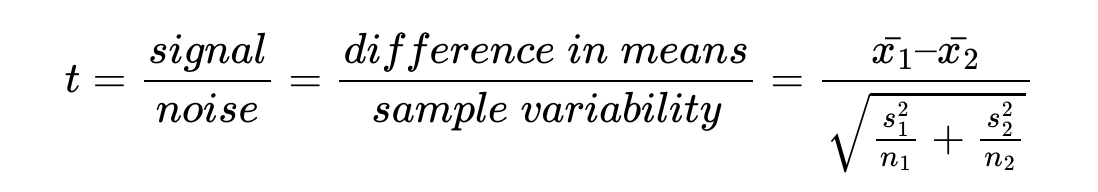

where, 
* **x̄1, x̄2** = sample means, 
* **s_1^2, s_2^2** = sample variances  
* **n_1, n_2** = sample sizes

**significance level (α)** = 0.05

In [ ]:
mean1, mean2 = statistics.mean(control_group['conversion']), statistics.mean(treatment_group['conversion'])
# Calculate mean of both the sample groups

std1, std2 = np.std(control_group['conversion'], ddof=1), np.std(treatment_group['conversion'], ddof=1)
# Calculate standard deviation of both the sample group

In [ ]:
# calculate standard errors
n1, n2 = len(control_group['conversion']), len(treatment_group['conversion'])
se1, se2 = std1/np.sqrt(n1), std2/np.sqrt(n2)

In [ ]:
# standard error on the difference between the samples
sed = np.sqrt(se1**2.0 + se2**2.0)

# calculate the t statistic
t_stat = (mean1 - mean2) / sed

In [ ]:
# degrees of freedom
df = n1 + n2 - 2

# calculate the critical value
alpha = 0.05
cv = t.ppf(1.0 - alpha, df)

In [ ]:
# calculate the p-value
p = (1 - t.cdf(abs(t_stat), df)) * 2

print("T-statstics : ",t_stat)
print("P-Value : ", p)
print("Critical value : ", cv)
print("Degree of freedom : ",df)

T-statstics :  1.3332412351723668
P-Value :  0.18931462543656385
Critical value :  1.6802299753652514
Degree of freedom :  44


**We got the same result as from using the function ttest_ind**